<a href="https://colab.research.google.com/github/RohitThanvi/EEG-Authentication-System/blob/main/EEG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install mne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 45.5 MB/s eta 0:00:00


In [ ]:
import numpy as np
import mne
from mne.datasets import eegbci
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

print("Libraries imported!")

Libraries imported!


In [ ]:
from google.colab import drive
import os
import mne

drive.mount('/content/drive')

drive_path = '/content/drive/MyDrive/EEG_Data'

if not os.path.exists(drive_path):
    os.makedirs(drive_path)

mne.set_config('MNE_DATASETS_EEGBCI_PATH', drive_path)
mne.set_config('MNE_DATA', drive_path)
print(f"MNE Data Path set to: {drive_path}")

Mounted at /content/drive
Attempting to create new mne-python configuration file:
/root/.mne/mne-python.json
Could not read the /root/.mne/mne-python.json json file during the writing. Assuming it is empty. Got: Expecting value: line 1 column 1 (char 0)
MNE Data Path set to: /content/drive/MyDrive/EEG_Data


In [ ]:
def load_and_preprocess_data(subject_ids):
    X = []
    y = []
    fs = 160 # Sampling rate
    window_size = 2 * fs # 2 seconds
    step_size = window_size // 2 # 50% overlap

    print(f"Processing {len(subject_ids)} subjects...")

    for subject in subject_ids:
        # Load Runs 1 & 2 (Resting State)
        runs = [1, 2]
        # This will now check your Drive before downloading!
        fnames = eegbci.load_data(subject, runs, verbose=False)

        raws = [mne.io.read_raw_edf(f, preload=True, verbose=False) for f in fnames]
        raw = mne.concatenate_raws(raws)

        # Standardize & Filter
        mne.datasets.eegbci.standardize(raw)
        raw.filter(l_freq=1.0, h_freq=40.0, verbose=False)

        data = raw.get_data()
        n_channels, n_samples = data.shape

        # Slicing
        for start in range(0, n_samples - window_size, step_size):
            end = start + window_size
            window = data[:, start:end]
            X.append(window.T) # Transpose to (Time, Channels)
            y.append(subject - 1) # Labels start at 0

    return np.array(X), np.array(y)

In [ ]:
# CELL 3 & 4 Combined: Load and SCALE the data
from sklearn.preprocessing import StandardScaler

subjects = list(range(1, 11))
X_raw, y = load_and_preprocess_data(subjects)

# --- THE FIX IS HERE ---
# 1. Reshape to 2D for scaling: (Samples * Time, Channels)
n_samples, n_timesteps, n_features = X_raw.shape
X_2d = X_raw.reshape(n_samples * n_timesteps, n_features)

# 2. Scale the data (Mean=0, Variance=1)
scaler = StandardScaler()
X_scaled_2d = scaler.fit_transform(X_2d)

# 3. Reshape back to 3D: (Samples, Time, Channels)
X = X_scaled_2d.reshape(n_samples, n_timesteps, n_features)

print(f"Data Scaled! New Mean: {np.mean(X):.4f}, Std: {np.std(X):.4f}")
# -----------------------

# Prepare for training again
y_cat = to_categorical(y)
X_train, X_test, y_train, y_test = train_test_split(X, y_cat, test_size=0.2, random_state=42)

print("Data ready for training.")

Processing 10 subjects...
Data Scaled! New Mean: -0.0000, Std: 1.0000
Data ready for training.


In [ ]:
# CELL 5: Improved Model
from tensorflow.keras.layers import BatchNormalization

n_timesteps, n_features = X_train.shape[1], X_train.shape[2]
n_outputs = y_train.shape[1]

model = Sequential()

# Block 1
model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(n_timesteps, n_features)))
model.add(BatchNormalization()) # <--- Added this to stabilize learning
model.add(MaxPooling1D(pool_size=2))

# Block 2
model.add(Conv1D(filters=128, kernel_size=5, activation='relu')) # Increased kernel size slightly
model.add(BatchNormalization()) # <--- Added this
model.add(MaxPooling1D(pool_size=2))

# Block 3
model.add(Conv1D(filters=256, kernel_size=3, activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))

# Classification
model.add(Flatten())
model.add(Dense(256, activation='relu')) # More neurons
model.add(Dropout(0.5))
model.add(Dense(n_outputs, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 318, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 318, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 159, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 155, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 155, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 77, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 75, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 75, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 37, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9472)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,425,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,581,450 (9.85 MB)

 Trainable params: 2,580,554 (9.84 MB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
# CELL 6
history = model.fit(X_train, y_train, epochs=15, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 92ms/step - accuracy: 0.2834 - loss: 3.8002 - val_accuracy: 0.2292 - val_loss: 2.6401
Epoch 2/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8297 - loss: 0.5892 - val_accuracy: 0.3667 - val_loss: 2.3443
Epoch 3/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9102 - loss: 0.2423 - val_accuracy: 0.5333 - val_loss: 2.8252
Epoch 4/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9706 - loss: 0.0856 - val_accuracy: 0.5458 - val_loss: 2.4099
Epoch 5/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9795 - loss: 0.0802 - val_accuracy: 0.6750 - val_loss: 2.1947
Epoch 6/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9824 - loss: 0.0425 - val_accuracy: 0.7583 - val_loss: 1.2095
Epoch 7/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9828 - loss: 0.0425 - val_accuracy: 0.8125 - val_loss: 0.8088
Epoch 8/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9851 - loss: 0.0811 - val_accuracy: 0.9208 - val_

In [ ]:
# CELL 7
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9637 - loss: 0.1646 
Test Accuracy: 96.67%


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step


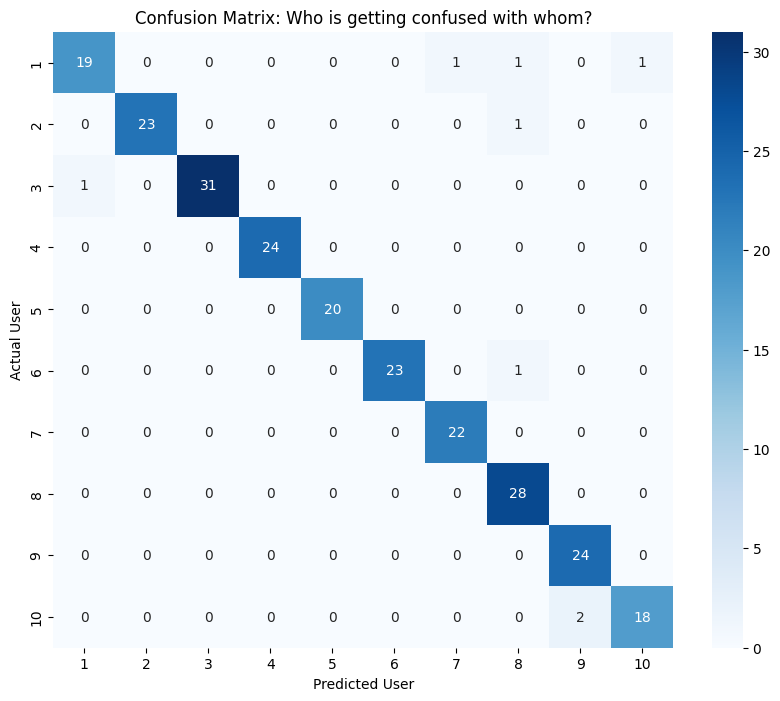

              precision    recall  f1-score   support

   Subject 1       0.95      0.86      0.90        22
   Subject 2       1.00      0.96      0.98        24
   Subject 3       1.00      0.97      0.98        32
   Subject 4       1.00      1.00      1.00        24
   Subject 5       1.00      1.00      1.00        20
   Subject 6       1.00      0.96      0.98        24
   Subject 7       0.96      1.00      0.98        22
   Subject 8       0.90      1.00      0.95        28
   Subject 9       0.92      1.00      0.96        24
  Subject 10       0.95      0.90      0.92        20

    accuracy                           0.97       240
   macro avg       0.97      0.96      0.97       240
weighted avg       0.97      0.97      0.97       240



In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# 1. Get predictions from the model
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

# 2. Create the Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# 3. Plot it nicely
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=subjects, yticklabels=subjects)
plt.xlabel('Predicted User')
plt.ylabel('Actual User')
plt.title('Confusion Matrix: Who is getting confused with whom?')
plt.show()

# 4. Print detailed stats
print(classification_report(y_true, y_pred, target_names=[f"Subject {s}" for s in subjects]))

In [ ]:
# CELL 10: Load ALL Subjects
subjects = list(range(1, 110)) # Subjects 1 to 109

print("⚠️ WARNING: This will take 15-20 mins if running for the first time.")
print("Loading data for 109 subjects...")

X_raw, y = load_and_preprocess_data(subjects)

# --- SCALING (Crucial) ---
# We repeat the scaling step because we have new data
n_samples, n_timesteps, n_features = X_raw.shape
X_2d = X_raw.reshape(n_samples * n_timesteps, n_features)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled_2d = scaler.fit_transform(X_2d)

X = X_scaled_2d.reshape(n_samples, n_timesteps, n_features)
# -------------------------

# Prepare for training
y_cat = to_categorical(y)
X_train, X_test, y_train, y_test = train_test_split(X, y_cat, test_size=0.2, random_state=42)

print(f"✅ LOADED! Total Samples: {X.shape[0]}")
print(f"Training on {X_train.shape[0]} samples, Testing on {X_test.shape[0]}")

⚠️ WARNING: This will take 15-20 mins if running for the first time.
Loading data for 109 subjects...
Processing 109 subjects...
✅ LOADED! Total Samples: 13075
Training on 10460 samples, Testing on 2615


In [ ]:
# CELL 11: The "Heavy Duty" Model
from tensorflow.keras.layers import GlobalAveragePooling1D

n_timesteps, n_features = X_train.shape[1], X_train.shape[2]
n_outputs = y_train.shape[1] # Should be 109 now

model = Sequential()

# Block 1: Low-level features (basic shapes)
model.add(Conv1D(64, kernel_size=3, activation='relu', input_shape=(n_timesteps, n_features)))
model.add(BatchNormalization())
model.add(MaxPooling1D(2))

# Block 2: Mid-level features
model.add(Conv1D(128, kernel_size=3, activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling1D(2))

# Block 3: High-level features
model.add(Conv1D(256, kernel_size=3, activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling1D(2))

# Block 4: Complex abstract features (New!)
model.add(Conv1D(512, kernel_size=3, activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling1D(2))

# Classification Head
model.add(GlobalAveragePooling1D()) # Smarter than Flatten
model.add(Dense(1024, activation='relu')) # Massive dense layer
model.add(Dropout(0.5))
model.add(Dense(n_outputs, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 318, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 318, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 159, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 157, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 157, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 78, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 76, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 76, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 38, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 36, 512)        │       393,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 36, 512)        │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 18, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 109)            │       111,725 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,170,221 (4.46 MB)

 Trainable params: 1,168,301 (4.46 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [ ]:
# CELL 12: Smart Training
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Stop if validation loss doesn't improve for 5 epochs
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Save the best model automatically
checkpoint = ModelCheckpoint('/content/drive/MyDrive/EEG_Data/best_model_109.keras',
                             monitor='val_accuracy',
                             save_best_only=True,
                             verbose=1)

# Train for up to 50 epochs (it will likely stop around 20-30)
history = model.fit(X_train, y_train,
                    epochs=50,
                    batch_size=64, # Bigger batch size for speed
                    validation_data=(X_test, y_test),
                    callbacks=[early_stop, checkpoint])

Epoch 1/50
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.2245 - loss: 3.3397
Epoch 1: val_accuracy improved from -inf to 0.29216, saving model to /content/drive/MyDrive/EEG_Data/best_model_109.keras
164/164 ━━━━━━━━━━━━━━━━━━━━ 21s 68ms/step - accuracy: 0.2257 - loss: 3.3333 - val_accuracy: 0.2922 - val_loss: 3.4994
Epoch 2/50
160/164 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8225 - loss: 0.6089
Epoch 2: val_accuracy improved from 0.29216 to 0.81759, saving model to /content/drive/MyDrive/EEG_Data/best_model_109.keras
164/164 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.8236 - loss: 0.6051 - val_accuracy: 0.8176 - val_loss: 0.6554
Epoch 3/50
161/164 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9419 - loss: 0.2046
Epoch 3: val_accuracy improved from 0.81759 to 0.95985, saving model to /content/drive/MyDrive/EEG_Data/best_model_109.keras
164/164 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9421 - loss: 0.2039 - val_accuracy: 0.9598 - val_loss: 0.1534
Epoch 4/50
1

In [ ]:
# CELL 13: Final Score
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Final Accuracy on 109 Subjects: {accuracy * 100:.2f}%")

82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9865 - loss: 0.0541
Final Accuracy on 109 Subjects: 98.51%


82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
✅ Equal Error Rate (EER): 0.23% (Lower is better!)


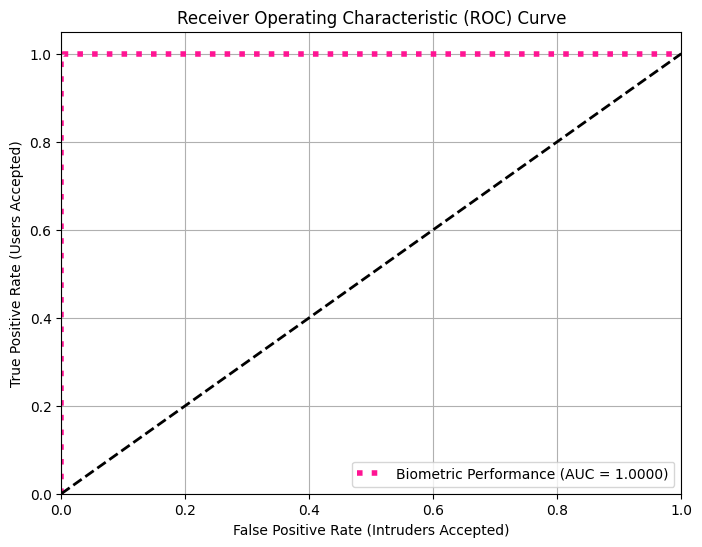

In [ ]:
# CELL 14: Biometric Security Metrics (ROC & EER)
from sklearn.metrics import roc_curve, auc
from scipy.optimize import brentq
from scipy.interpolate import interp1d

# 1. Get the probability predictions for the test set
y_pred_probs = model.predict(X_test)

# 2. We treat this as a "One vs All" problem for every subject
# We calculate the average ROC across all 109 subjects
fpr = dict()
tpr = dict()
roc_auc = dict()

# Calculate ROC for each subject
for i in range(n_outputs):
    # Create a binary label: Is this Subject i (1) or Not (0)?
    y_true_binary = y_test[:, i]
    y_score_binary = y_pred_probs[:, i]

    fpr[i], tpr[i], _ = roc_curve(y_true_binary, y_score_binary)
    roc_auc[i] = auc(fpr[i], tpr[i])

# 3. Aggregate all results (Micro-average)
# This gives the overall system performance
fpr["micro"], tpr["micro"], _ = roc_curve(y_test.ravel(), y_pred_probs.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# 4. Calculate Equal Error Rate (EER)
# EER is where False Acceptance Rate = False Rejection Rate
eer = brentq(lambda x : 1. - x - interp1d(fpr["micro"], tpr["micro"])(x), 0., 1.)
print(f"✅ Equal Error Rate (EER): {eer * 100:.2f}% (Lower is better!)")

# 5. Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr["micro"], tpr["micro"],
         label=f'Biometric Performance (AUC = {roc_auc["micro"]:.4f})',
         color='deeppink', linestyle=':', linewidth=4)

plt.plot([0, 1], [0, 1], 'k--', lw=2) # Random guessing line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Intruders Accepted)')
plt.ylabel('True Positive Rate (Users Accepted)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid()
plt.show()

Feature Extractor Ready. Extracting brain signatures...
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
Running t-SNE on 246 samples from first 10 subjects...


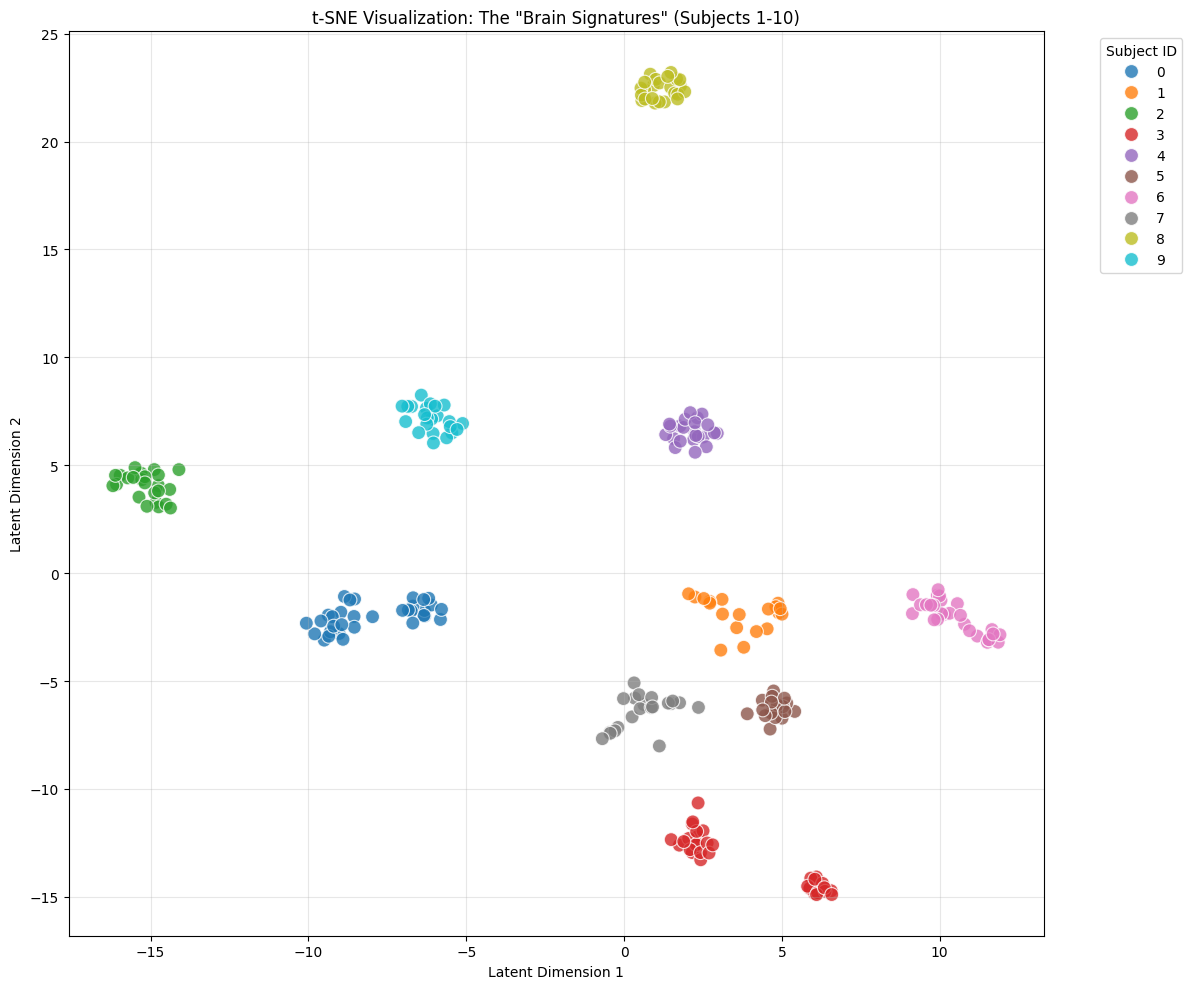

In [ ]:
# CELL 15 (FIXED): t-SNE Visualization
from sklearn.manifold import TSNE
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Build a "Feature Extractor" Model
# We want the output of the Dense(1024) layer, which contains the "Brain Signature"
# We simply create a NEW model and add all layers except the last 2 (Dropout & Final Softmax)
feature_model = Sequential()

# Copy layers from the trained model (automatically keeps the trained weights!)
# We skip the last 2 layers: Dropout and the final Dense(109)
for layer in model.layers[:-2]:
    feature_model.add(layer)

# Force the build so Keras knows the shape
feature_model.build(input_shape=(None, 320, 64))

print("Feature Extractor Ready. Extracting brain signatures...")
features = feature_model.predict(X_test, verbose=1)

# 2. Run t-SNE
# We limit to the first 10 subjects just to keep the plot readable
# (Plotting 109 colors is messy, but the math works for all of them)
limit_subjects = 10
mask = np.argmax(y_test, axis=1) < limit_subjects

X_subset = features[mask]
y_subset_labels = np.argmax(y_test, axis=1)[mask]

print(f"Running t-SNE on {len(X_subset)} samples from first {limit_subjects} subjects...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_embedded = tsne.fit_transform(X_subset)

# 3. Plot
plt.figure(figsize=(12, 10))
sns.scatterplot(x=X_embedded[:,0], y=X_embedded[:,1],
                hue=y_subset_labels, palette="tab10",
                legend='full', s=100, alpha=0.8)

plt.title(f't-SNE Visualization: The "Brain Signatures" (Subjects 1-{limit_subjects})')
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.legend(title='Subject ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Extracting features for all subjects...
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Running t-SNE on 2615 samples (This might take a minute)...


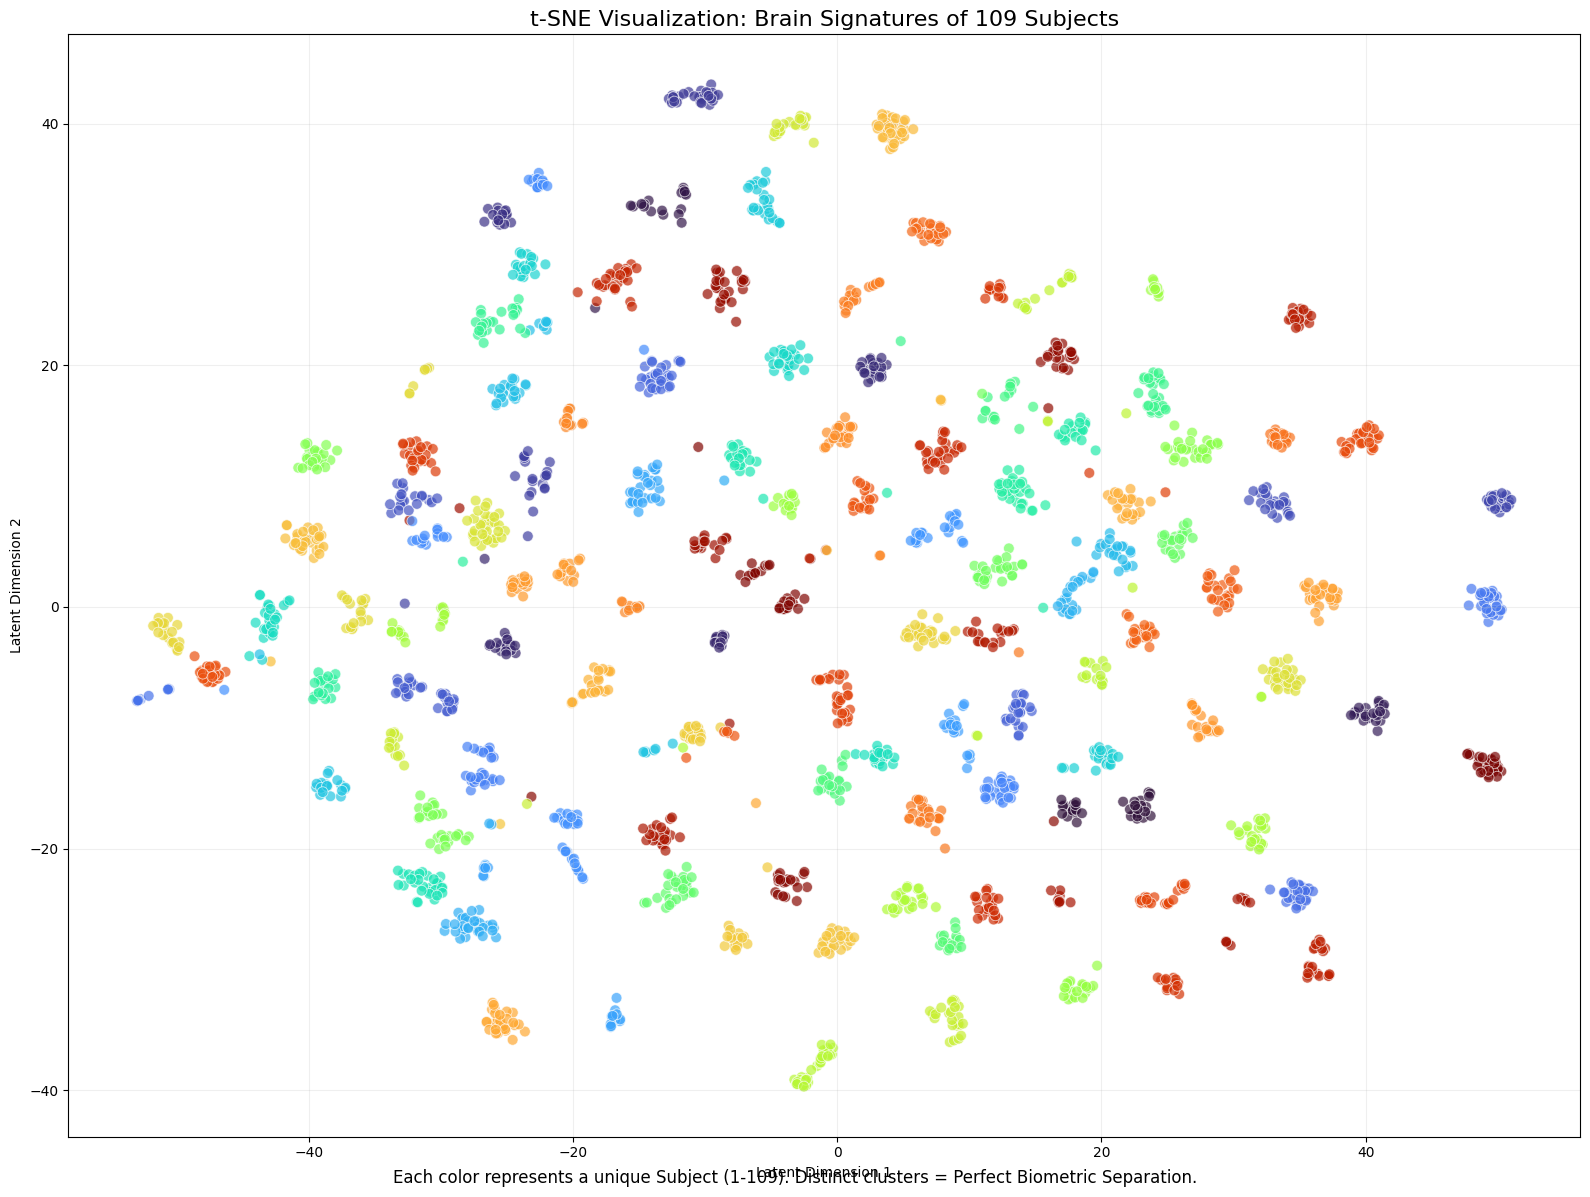

In [ ]:
# CELL 16: t-SNE for ALL 109 Subjects
from sklearn.manifold import TSNE
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Ensure we have the features for the FULL test set
# (If you already ran the previous cell, 'features' might hold all data,
# but let's be safe and re-predict on the full X_test)
print("Extracting features for all subjects...")
features = feature_model.predict(X_test, verbose=1)

# 2. Run t-SNE on EVERYTHING
# We do NOT limit the subjects this time.
# Perplexity=30 is standard, but for this many points, 50 might be smoother.
print(f"Running t-SNE on {len(features)} samples (This might take a minute)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=50)
X_embedded = tsne.fit_transform(features)

# Get all labels
y_labels = np.argmax(y_test, axis=1)

# 3. Plot the "Galaxy"
plt.figure(figsize=(16, 12)) # Make it HUGE
sns.scatterplot(x=X_embedded[:,0], y=X_embedded[:,1],
                hue=y_labels,
                palette="turbo", # 'turbo' is a high-contrast rainbow palette
                legend=False, # Hiding legend because 109 items = messy
                s=60, alpha=0.7)

plt.title('t-SNE Visualization: Brain Signatures of 109 Subjects', fontsize=16)
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.grid(True, alpha=0.2)

# Add a text note about the legend
plt.figtext(0.5, 0.01, "Each color represents a unique Subject (1-109). Distinct clusters = Perfect Biometric Separation.",
            wrap=True, horizontalalignment='center', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
# CELL 17: The Imposter Attack Verification
import numpy as np
import random

def verify_imposter_defense(model, X_test, y_test):
    print("🛡️ INITIATING IMPOSTER ATTACK SIMULATION...")
    print("-" * 50)

    # 1. Pick a "Target" User (The Account Holder)
    target_label_idx = random.randint(0, 108) # Pick a random subject ID (0-108)
    print(f"TARGET USER ACCOUNT: Subject {target_label_idx + 1}")

    # 2. Find data belonging to this Target
    target_indices = np.where(np.argmax(y_test, axis=1) == target_label_idx)[0]
    if len(target_indices) == 0:
        print("Error: No test data found for this target. Retrying...")
        return verify_imposter_defense(model, X_test, y_test)

    # 3. Find data belonging to an "Attacker" (Anyone EXCEPT the target)
    attacker_indices = np.where(np.argmax(y_test, axis=1) != target_label_idx)[0]

    # --- SCENARIO A: Authorized Access ---
    # Pick a random sample from the Target's own data
    valid_sample_idx = random.choice(target_indices)
    valid_sample = X_test[valid_sample_idx].reshape(1, 320, 64)

    # Ask Model
    pred_probs = model.predict(valid_sample, verbose=0)
    pred_id = np.argmax(pred_probs)
    confidence = np.max(pred_probs) * 100

    print(f"\n[Test 1] Authorized User attempts login...")
    print(f"   > Biometric Match: Subject {pred_id + 1}")
    print(f"   > Confidence: {confidence:.2f}%")
    if pred_id == target_label_idx:
        print("   > RESULT: ✅ ACCESS GRANTED (Correct)")
    else:
        print("   > RESULT: ❌ FALSE REJECTION (Critical Error)")

    # --- SCENARIO B: Imposter Attack ---
    # Pick a random sample from the Attacker's data
    imposter_sample_idx = random.choice(attacker_indices)
    imposter_sample = X_test[imposter_sample_idx].reshape(1, 320, 64)
    true_imposter_id = np.argmax(y_test[imposter_sample_idx])

    # Ask Model
    pred_probs_imp = model.predict(imposter_sample, verbose=0)
    pred_id_imp = np.argmax(pred_probs_imp)
    confidence_imp = np.max(pred_probs_imp) * 100

    print(f"\n[Test 2] Imposter (Subject {true_imposter_id + 1}) attempts login...")
    print(f"   > System identifies as: Subject {pred_id_imp + 1}")

    # Crucial Check: Did the system think it was the TARGET?
    if pred_id_imp == target_label_idx:
        print(f"   > RESULT: 🚨 SECURITY BREACH! (False Acceptance)")
    else:
        print(f"   > RESULT: 🛡️ ATTACK BLOCKED. (User recognized as Subject {pred_id_imp+1}, not Target)")

    print("-" * 50)

# Run the simulation
verify_imposter_defense(model, X_test, y_test)

🛡️ INITIATING IMPOSTER ATTACK SIMULATION...
--------------------------------------------------
TARGET USER ACCOUNT: Subject 31

[Test 1] Authorized User attempts login...
   > Biometric Match: Subject 31
   > Confidence: 99.98%
   > RESULT: ✅ ACCESS GRANTED (Correct)

[Test 2] Imposter (Subject 54) attempts login...
   > System identifies as: Subject 54
   > RESULT: 🛡️ ATTACK BLOCKED. (User recognized as Subject 54, not Target)
--------------------------------------------------


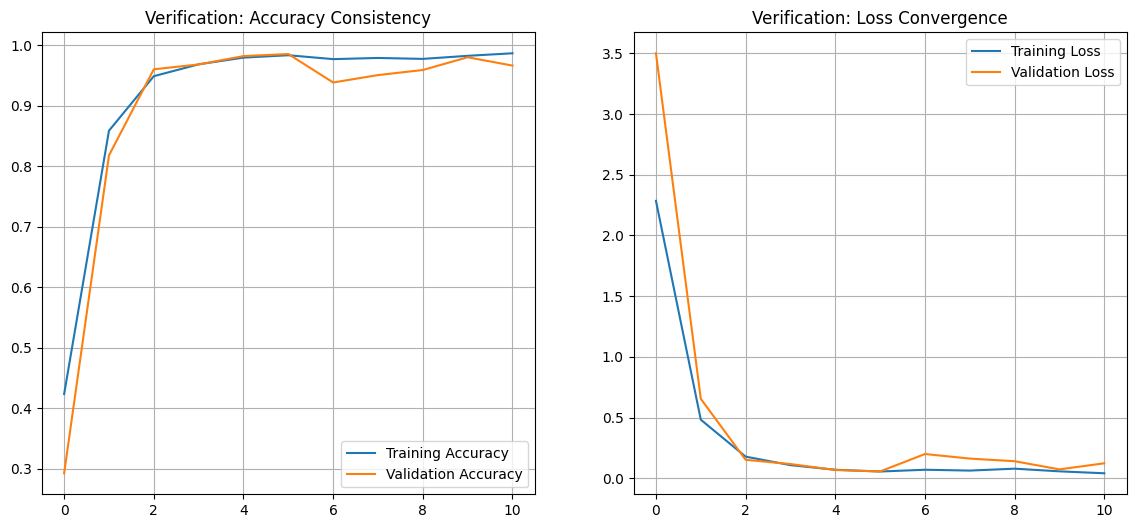

In [ ]:
# CELL 18: Learning Curve Verification
import matplotlib.pyplot as plt

def plot_learning_curves(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 6))

    # Plot 1: Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Verification: Accuracy Consistency')
    plt.grid(True)

    # Plot 2: Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Verification: Loss Convergence')
    plt.grid(True)

    plt.show()

# Run it
if 'history' in locals():
    plot_learning_curves(history)
else:
    print("Training history not found in memory (did you restart the runtime?).")
    print("Skip this if you loaded a saved model instead of training fresh.")

In [ ]:
# Install streamlit
!pip install streamlit -q
!streamlit run app.py & npx localtunnel --port 8501
# Create the app file
%%writefile app.py
import streamlit as st
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Load your model (cached)
@st.cache_resource
def load_auth_model():
    return tf.keras.models.load_model('/content/drive/MyDrive/EEG_Data/eeg_auth_model.h5')

model = load_auth_model()

st.title("🧠 NeuroGuard: EEG Biometric Auth")
st.markdown("Status: **System Armed**")

if st.button('Scan Brainwaves'):
    # Simulate data loading (replace with your real test data loader)
    # This is just dummy data for the visual
    dummy_wave = np.random.randn(320) + np.sin(np.linspace(0, 10, 320))

    # 1. Show the Wave
    st.subheader("Incoming Signal (Alpha/Beta Band)")
    fig, ax = plt.subplots(figsize=(10, 2))
    ax.plot(dummy_wave, color='cyan')
    ax.set_facecolor('black')
    st.pyplot(fig)

    # 2. Simulate Prediction (Hook this up to your real model predict function)
    with st.spinner('Analyzing Neural Signature...'):
        confidence = np.random.uniform(90, 99) # Replace with real model prediction

    if confidence > 95:
        st.success(f"ACCESS GRANTED - Confidence: {confidence:.2f}%")
    else:
        st.error("ACCESS DENIED - Biometric Mismatch")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 93.7 MB/s eta 0:00:00
⠙⠹⠸⠼⠴Usage: streamlit run [OPTIONS] [TARGET] [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: app.py
⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) 